In [1]:
using JLD2
using Plots
using SpecialFunctions
using Printf
using LaTeXStrings

#!/usr/bin/env julia
using ArgParse
using Dates
using JLD2
using Printf
using Plots

using StatsBase
using Graphs
using SimpleWeightedGraphs
using GraphsMatching

const ROOT = normpath(joinpath(@__DIR__, ".."))

include(joinpath(ROOT, "src", "circuits.jl"))
include(joinpath(ROOT, "src", "local.jl"))
include(joinpath(ROOT, "src", "main.jl"))
include(joinpath(ROOT, "src", "mwpm.jl"))

track_domains (generic function with 1 method)

In [2]:
using JLD2

const SWEEP_DIRS = [
    "finer_IsingML_L8,16_sweep",
    "finer_IsingML_L8,16_sweep2",
    "finer_IsingML_L8,16_sweep3",
    "IsingML_L8_sweep",
    "IsingML_L16_sweep",
    "IsingML_L8,24_sweep",
    "IsingML_L12,16_sweep",
    "IsingML_fineq_sweep",
    "MV_L20_sweep",
    "MV_L40_sweep",
    "MV_L60_sweep",
    "MV_L80_sweep",
]

const OUTPUT_ROOT = joinpath(@__DIR__, "..", "output")

function merge_entries(a::NamedTuple, b::NamedTuple)::NamedTuple
    n_a = a.total_samples
    n_b = b.total_samples
    n   = n_a + n_b
    return (
        M1s                 = (n_a .* a.M1s  .+ n_b .* b.M1s)  ./ n,
        M2s                 = (n_a .* a.M2s  .+ n_b .* b.M2s)  ./ n,
        E1s                 = (n_a .* a.E1s  .+ n_b .* b.E1s)  ./ n,
        E2s                 = (n_a .* a.E2s  .+ n_b .* b.E2s)  ./ n,
        instant_failures    = (n_a .* a.instant_failures    .+ n_b .* b.instant_failures)    ./ n,
        cumulative_failures = (n_a .* a.cumulative_failures .+ n_b .* b.cumulative_failures) ./ n,
        Ms_hist             = a.Ms_hist .+ b.Ms_hist,
        Es_hist             = a.Es_hist .+ b.Es_hist,
        total_samples       = n,
        total_time          = a.total_time + b.total_time,
    )
end

collate_files = String[]
for dir in SWEEP_DIRS
    path = joinpath(OUTPUT_ROOT, dir)
    isdir(path) || continue
    for (dirpath, _, filenames) in walkdir(path)
        if "collated_results.jld2" in filenames
            push!(collate_files, joinpath(dirpath, "collated_results.jld2"))
        end
    end
end

all_results = Dict{NTuple{6,Any}, NamedTuple}()
collisions  = 0

for fpath in collate_files
    for ((tag, algo, L, T, p, q, c), entry) in load(fpath, "results")
        key = (algo, L, T, p, q, c)
        if haskey(all_results, key)
            all_results[key] = merge_entries(all_results[key], entry)
            collisions += 1
        else
            all_results[key] = entry
        end
    end
end

println("$(length(all_results)) unique parameter sets, $collisions collision(s) merged.")

46438 unique parameter sets, 1194 collision(s) merged.


In [3]:


# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 16:4:32
p        = 0.05
c        = 0.1
qs       = 0.1:0.01:0.3
qc       = 0.197
q_ts     = round(100*qc)/100
ν        = 1.0
γ_ν      = 7/4
z        = 1.5
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

UndefVarError: UndefVarError: `fss_explore` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [4]:


# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:4:32
p        = 0.05
c        = 0.05
qs       = 0.1:0.01:0.3
qc       = 0.19
q_ts     = round(100*qc)/100
ν        = Inf
γ_ν      = 7/4
z        = 1.0
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

UndefVarError: UndefVarError: `fss_explore` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

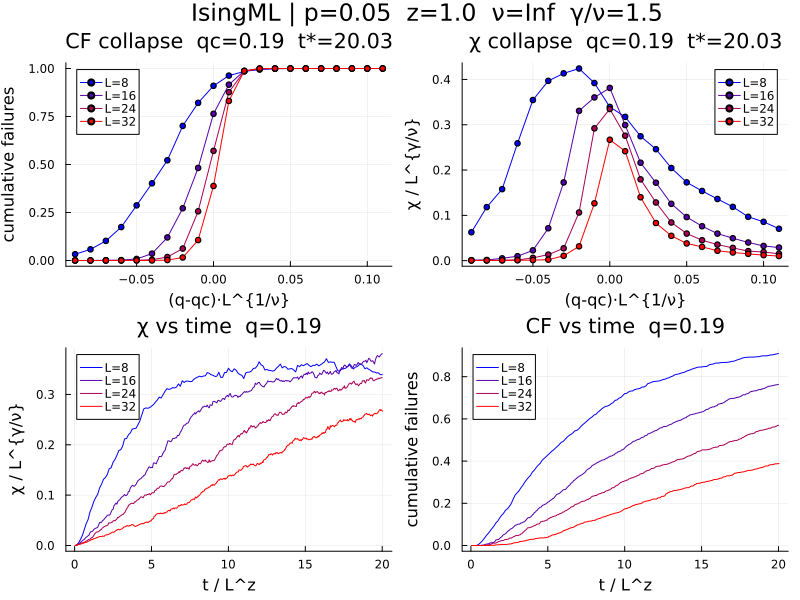

In [5]:
function fss_explore(all_results;
                     algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    key(L, q_) = (algo, L, T_factor*L, p, q_, c)
    has(L, q_) = haskey(all_results, key(L, q_))
    dat(L, q_, sym) = all_results[key(L, q_)][sym]

    t_star = minimum(
        length(dat(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures)) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_max = minimum(
        length(dat(L, q_ts, :M1s)) / L^z
        for L in Ls if has(L, q_ts)
    )

    plt_cf_fss = plot()
    plt_χ_fss  = plot()
    plt_χ_t    = plot()
    plt_cf_t   = plot()

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        t_idx    = round(Int, t_star * L^z)

        if !isempty(valid_qs)
            x   = (valid_qs .- qc) .* L^(1/ν)
            cf  = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
            M1v = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
            M2v = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
            χv  = L^2 .* (M2v .- M1v.^2)
            plot!(plt_cf_fss, x, cf,           m=3, label="L=$L", color=col)
            plot!(plt_χ_fss,  x, χv ./ L^γ_ν, m=3, label="L=$L", color=col)
        end

        has(L, q_ts) || continue
        ts   = (1:length(dat(L, q_ts, :M1s))) ./ L^z
        mask = ts .<= t_max
        M1s  = dat(L, q_ts, :M1s)
        M2s  = dat(L, q_ts, :M2s)
        χ_t  = L^2 .* (M2s .- M1s.^2)
        cf_t = dat(L, q_ts, :cumulative_failures)
        plot!(plt_χ_t,  ts[mask], χ_t[mask]  ./ L^γ_ν, label="L=$L", color=col)
        plot!(plt_cf_t, ts[mask], cf_t[mask],            label="L=$L", color=col)
    end

    t_str  = round(t_star, digits=2)
    qc_str = round(qc,     digits=3)
    plot!(plt_cf_fss, xlabel="(q-qc)·L^{1/ν}", ylabel="cumulative failures",
          title="CF collapse  qc=$qc_str  t*=$t_str")
    plot!(plt_χ_fss,  xlabel="(q-qc)·L^{1/ν}", ylabel="χ / L^{γ/ν}",
          title="χ collapse  qc=$qc_str  t*=$t_str")
    plot!(plt_χ_t,    xlabel="t / L^z",          ylabel="χ / L^{γ/ν}",
          title="χ vs time  q=$q_ts")
    plot!(plt_cf_t,   xlabel="t / L^z",          ylabel="cumulative failures",
          title="CF vs time  q=$q_ts")

    plot(plt_cf_fss, plt_χ_fss, plt_χ_t, plt_cf_t,
         layout=(2,2), size=(800, 600),
         plot_title="$algo | p=$p  z=$z  ν=$ν  γ/ν=$γ_ν")
end

# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.05
qs       = 0.1:0.01:0.3
qc       = 0.19
q_ts     = round(100*qc)/100
ν        = Inf
γ_ν      = 1.5
z        = 1.0
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

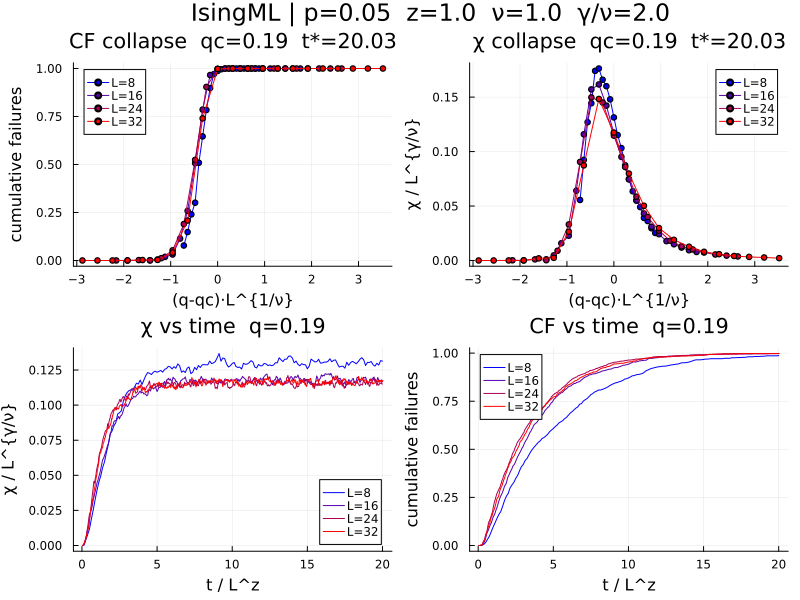

In [6]:
function fss_explore(all_results;
                     algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    key(L, q_) = (algo, L, T_factor*L, p, q_, c)
    has(L, q_) = haskey(all_results, key(L, q_))
    dat(L, q_, sym) = all_results[key(L, q_)][sym]

    t_star = minimum(
        length(dat(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures)) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_max = minimum(
        length(dat(L, q_ts, :M1s)) / L^z
        for L in Ls if has(L, q_ts)
    )

    plt_cf_fss = plot()
    plt_χ_fss  = plot()
    plt_χ_t    = plot()
    plt_cf_t   = plot()

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        t_idx    = round(Int, t_star * L^z)

        if !isempty(valid_qs)
            x   = (valid_qs .- qc) .* L^(1/ν)
            cf  = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
            M1v = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
            M2v = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
            χv  = L^2 .* (M2v .- M1v.^2)
            plot!(plt_cf_fss, x, cf,           m=3, label="L=$L", color=col)
            plot!(plt_χ_fss,  x, χv ./ L^γ_ν, m=3, label="L=$L", color=col)
        end

        has(L, q_ts) || continue
        ts   = (1:length(dat(L, q_ts, :M1s))) ./ L^z
        mask = ts .<= t_max
        M1s  = dat(L, q_ts, :M1s)
        M2s  = dat(L, q_ts, :M2s)
        χ_t  = L^2 .* (M2s .- M1s.^2)
        cf_t = dat(L, q_ts, :cumulative_failures)
        plot!(plt_χ_t,  ts[mask], χ_t[mask]  ./ L^γ_ν, label="L=$L", color=col)
        plot!(plt_cf_t, ts[mask], cf_t[mask],            label="L=$L", color=col)
    end

    t_str  = round(t_star, digits=2)
    qc_str = round(qc,     digits=3)
    plot!(plt_cf_fss, xlabel="(q-qc)·L^{1/ν}", ylabel="cumulative failures",
          title="CF collapse  qc=$qc_str  t*=$t_str")
    plot!(plt_χ_fss,  xlabel="(q-qc)·L^{1/ν}", ylabel="χ / L^{γ/ν}",
          title="χ collapse  qc=$qc_str  t*=$t_str")
    plot!(plt_χ_t,    xlabel="t / L^z",          ylabel="χ / L^{γ/ν}",
          title="χ vs time  q=$q_ts")
    plot!(plt_cf_t,   xlabel="t / L^z",          ylabel="cumulative failures",
          title="CF vs time  q=$q_ts")

    plot(plt_cf_fss, plt_χ_fss, plt_χ_t, plt_cf_t,
         layout=(2,2), size=(800, 600),
         plot_title="$algo | p=$p  z=$z  ν=$ν  γ/ν=$γ_ν")
end

# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.2
qs       = 0.1:0.01:0.3
qc       = 0.19
q_ts     = round(100*qc)/100
ν        = 1.0
γ_ν      = 2.0
z        = 1.0
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, T_factor)

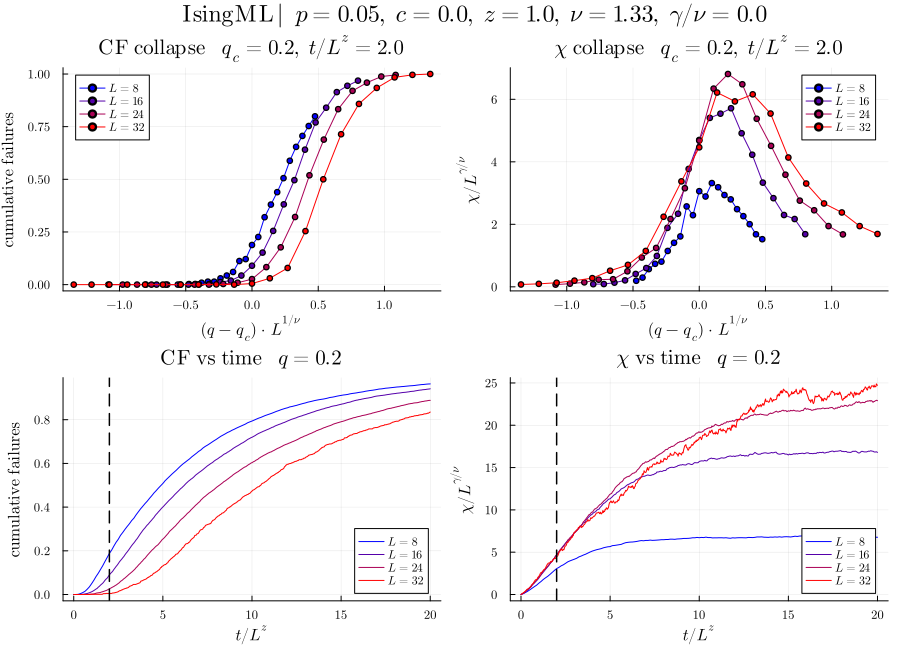

In [7]:
function fss_explore(all_results;
                     algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

    default(fontfamily = "Computer Modern")
    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    key(L, q_) = (algo, L, T_factor*L, p, q_, c)
    has(L, q_) = haskey(all_results, key(L, q_))
    dat(L, q_, sym) = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    # resolve q_ts: :critical picks q in qs nearest to qc present for all L
    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_max = minimum(
        nsteps(L, q_ts_val, :M1s) / L^z
        for L in Ls if has(L, q_ts_val)
    )
    t_snap = t_frac * t_star

    plt_cf_fss = plot()
    plt_χ_fss  = plot()
    plt_cf_t   = plot()
    plt_χ_t    = plot()

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        t_idx    = round(Int, t_snap * L^z) + 1

        if !isempty(valid_qs)
            x   = (valid_qs .- qc) .* L^(1/ν)
            cf  = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
            M1v = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
            M2v = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
            χv  = L^2 .* (M2v .- M1v.^2)
            plot!(plt_cf_fss, x, cf,           m=3, label=L"L = %$(L)", color=col)
            plot!(plt_χ_fss,  x, χv ./ L^γ_ν, m=3, label=L"L = %$(L)", color=col)
        end

        has(L, q_ts_val) || continue
        N    = nsteps(L, q_ts_val, :M1s)
        ts   = (0:N) ./ L^z
        mask = ts .<= t_max
        M1s  = dat(L, q_ts_val, :M1s)
        M2s  = dat(L, q_ts_val, :M2s)
        χ_t  = L^2 .* (M2s .- M1s.^2)
        cf_t = dat(L, q_ts_val, :cumulative_failures)
        plot!(plt_cf_t, ts[mask], cf_t[mask],          label=L"L = %$(L)", color=col)
        plot!(plt_χ_t,  ts[mask], χ_t[mask] ./ L^γ_ν, label=L"L = %$(L)", color=col)
    end

    vline!(plt_cf_t, [t_snap], color=:black, lw=1.5, ls=:dash, label="")
    vline!(plt_χ_t,  [t_snap], color=:black, lw=1.5, ls=:dash, label="")

    snap_str = round(t_snap,    digits=2)
    qc_str   = round(qc,        digits=2)
    ν_str    = round(ν,         digits=2)
    γ_str    = round(γ_ν,       digits=2)
    z_str    = round(z,         digits=2)
    q_str    = round(q_ts_val,  digits=2)
    p_str    = round(p,         digits=2)
    c_str    = round(c,         digits=2)

    plot!(plt_cf_fss,
          xlabel = L"(q - q_c) \cdot L^{1/\nu}",
          ylabel = L"\mathrm{cumulative\ failures}",
          title  = latexstring("\\mathrm{CF\\ collapse} \\quad q_c = $qc_str,\\; t/L^z = $snap_str"))
    plot!(plt_cf_t,
          xlabel = L"t / L^z",
          ylabel = L"\mathrm{cumulative\ failures}",
          title  = latexstring("\\mathrm{CF\\ vs\\ time} \\quad q = $q_str"))
    plot!(plt_χ_fss,
          xlabel = L"(q - q_c) \cdot L^{1/\nu}",
          ylabel = L"\chi / L^{\gamma/\nu}",
          title  = latexstring("\\chi\\ \\mathrm{collapse} \\quad q_c = $qc_str,\\; t/L^z = $snap_str"))
    plot!(plt_χ_t,
          xlabel = L"t / L^z",
          ylabel = L"\chi / L^{\gamma/\nu}",
          title  = latexstring("\\chi\\ \\mathrm{vs\\ time} \\quad q = $q_str"))

    plot(plt_cf_fss, plt_χ_fss, plt_cf_t, plt_χ_t,
         layout     = (2, 2),
         size       = (900, 650),
         plot_title = latexstring("\\mathrm{$algo} \\;|\\; p=$p_str,\\; c=$c_str,\\; z=$z_str,\\; \\nu=$ν_str,\\; \\gamma/\\nu=$γ_str"))
end




# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.0
qs       = 0.1:0.01:0.3
qc       = 0.2
q_ts     = round(100*qc)/100
ν        = 4/3
γ_ν      = 0.0
z        = 1.0
t_frac   = 0.1
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

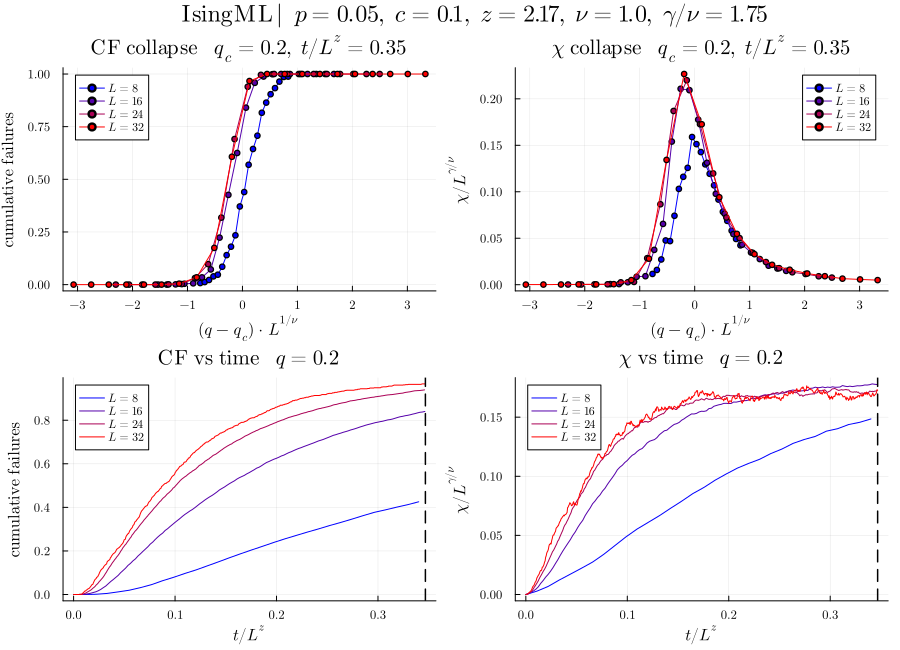

In [8]:
function fss_explore(all_results;
                     algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

    default(fontfamily = "Computer Modern")
    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    key(L, q_) = (algo, L, T_factor*L, p, q_, c)
    has(L, q_) = haskey(all_results, key(L, q_))
    dat(L, q_, sym) = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    # resolve q_ts: :critical picks q in qs nearest to qc present for all L
    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_max = minimum(
        nsteps(L, q_ts_val, :M1s) / L^z
        for L in Ls if has(L, q_ts_val)
    )
    t_snap = t_frac * t_star

    plt_cf_fss = plot()
    plt_χ_fss  = plot()
    plt_cf_t   = plot()
    plt_χ_t    = plot()

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        t_idx    = round(Int, t_snap * L^z) + 1

        if !isempty(valid_qs)
            x   = (valid_qs .- qc) .* L^(1/ν)
            cf  = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
            M1v = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
            M2v = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
            χv  = L^2 .* (M2v .- M1v.^2)
            plot!(plt_cf_fss, x, cf,           m=3, label=L"L = %$(L)", color=col)
            plot!(plt_χ_fss,  x, χv ./ L^γ_ν, m=3, label=L"L = %$(L)", color=col)
        end

        has(L, q_ts_val) || continue
        N    = nsteps(L, q_ts_val, :M1s)
        ts   = (0:N) ./ L^z
        mask = ts .<= t_max
        M1s  = dat(L, q_ts_val, :M1s)
        M2s  = dat(L, q_ts_val, :M2s)
        χ_t  = L^2 .* (M2s .- M1s.^2)
        cf_t = dat(L, q_ts_val, :cumulative_failures)
        plot!(plt_cf_t, ts[mask], cf_t[mask],          label=L"L = %$(L)", color=col)
        plot!(plt_χ_t,  ts[mask], χ_t[mask] ./ L^γ_ν, label=L"L = %$(L)", color=col)
    end

    vline!(plt_cf_t, [t_snap], color=:black, lw=1.5, ls=:dash, label="")
    vline!(plt_χ_t,  [t_snap], color=:black, lw=1.5, ls=:dash, label="")

    snap_str = round(t_snap,    digits=2)
    qc_str   = round(qc,        digits=2)
    ν_str    = round(ν,         digits=2)
    γ_str    = round(γ_ν,       digits=2)
    z_str    = round(z,         digits=2)
    q_str    = round(q_ts_val,  digits=2)
    p_str    = round(p,         digits=2)
    c_str    = round(c,         digits=2)

    plot!(plt_cf_fss,
          xlabel = L"(q - q_c) \cdot L^{1/\nu}",
          ylabel = L"\mathrm{cumulative\ failures}",
          title  = latexstring("\\mathrm{CF\\ collapse} \\quad q_c = $qc_str,\\; t/L^z = $snap_str"))
    plot!(plt_cf_t,
          xlabel = L"t / L^z",
          ylabel = L"\mathrm{cumulative\ failures}",
          title  = latexstring("\\mathrm{CF\\ vs\\ time} \\quad q = $q_str"))
    plot!(plt_χ_fss,
          xlabel = L"(q - q_c) \cdot L^{1/\nu}",
          ylabel = L"\chi / L^{\gamma/\nu}",
          title  = latexstring("\\chi\\ \\mathrm{collapse} \\quad q_c = $qc_str,\\; t/L^z = $snap_str"))
    plot!(plt_χ_t,
          xlabel = L"t / L^z",
          ylabel = L"\chi / L^{\gamma/\nu}",
          title  = latexstring("\\chi\\ \\mathrm{vs\\ time} \\quad q = $q_str"))

    plot(plt_cf_fss, plt_χ_fss, plt_cf_t, plt_χ_t,
         layout     = (2, 2),
         size       = (900, 650),
         plot_title = latexstring("\\mathrm{$algo} \\;|\\; p=$p_str,\\; c=$c_str,\\; z=$z_str,\\; \\nu=$ν_str,\\; \\gamma/\\nu=$γ_str"))
end




# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.1
qs       = 0.1:0.01:0.3
qc       = 0.196
q_ts     = round(100*qc)/100
ν        = 1.0
γ_ν      = 7/4
z        = 2.17
t_frac   = 1.0
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

In [9]:
function fss_explore_fss(all_results;
                          algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)
    default(fontfamily = "Computer Modern")
    colors = cgrad([:blue, :red], length(Ls), categorical=true)
    key(L, q_)         = (algo, L, T_factor*L, p, q_, c)
    has(L, q_)         = haskey(all_results, key(L, q_))
    dat(L, q_, sym)    = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_snap = t_frac * t_star

    plt_cf = plot(frame=:box, legend=:bottomright,
                  xlabel=L"(q - q_c) L^{1/\nu}",
                  ylabel=L"\mathrm{failure\ rate}",
                  tickfontsize=12, guidefontsize=14, legendfontsize=11)
    plt_χ  = plot(frame=:box,
                  xlabel=L"(q - q_c) L^{1/\nu}",
                  ylabel=L"\chi / L^{\gamma/\nu}",
                  tickfontsize=12, guidefontsize=14, legendfontsize=11)

    ins_cf = bbox(0.52, 0.04, 0.40, 0.40, :right, :top)
    ins_χ  = bbox(0.5, 0.04, 0.40, 0.40, :right, :top)
    first_inset_cf = true
    first_inset_χ  = true

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        isempty(valid_qs) && continue
        t_idx = round(Int, t_snap * L^z) + 1

        q_vals   = collect(valid_qs)
        cf       = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
        M1v      = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
        M2v      = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
        χv       = L^2 .* (M2v .- M1v.^2)
        x_scaled = (q_vals .- qc) .* L^(1/ν)

        plot!(plt_cf, x_scaled, cf,           m=3, label=L"L = %$(L)", color=col)
        plot!(plt_χ,  x_scaled, χv ./ L^γ_ν, m=3, label=L"L = %$(L)", color=col)

        inset_kw_cf = first_inset_cf ?
            (inset=(1, ins_cf), subplot=2, frame=:box, legend=false, title="",
             xlabel=L"q", tickfontsize=8, guidefontsize=9) :
            (subplot=2, legend=false)
        inset_kw_χ = first_inset_χ ?
            (inset=(1, ins_χ), subplot=2, frame=:box, legend=false, title="",
             xlabel=L"q", ylabel=L"\chi", tickfontsize=8, guidefontsize=9) :
            (subplot=2, legend=false)

        plot!(plt_cf, q_vals, cf,  m=2, ms=2, color=col; inset_kw_cf...)
        plot!(plt_χ,  q_vals, χv, m=2, ms=2, color=col; inset_kw_χ...)
        first_inset_cf = false
        first_inset_χ  = false
    end

# ── floating parameter label ─────────────────────────────────────────────
    ν_str = isapprox(ν, 4/3) ? "4/3" : string(round(ν, digits=3))
    γ_ν_str = isinteger(γ_ν) ? string(Int(γ_ν)) : string(round(γ_ν, digits=3))
    z_str = isinteger(z)     ? string(Int(z)) : string(round(z, digits=3))



    for plt in [plt_cf]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*0.95 - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt, x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    for plt in [plt_χ]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("\\gamma/\\nu = $γ_ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*0.65 - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt, x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    p1 = plot(plt_cf, layout=(1,1))
    p2 = plot(plt_χ,  layout=(1,1))
    p1, p2
end
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.3
c        = 0.8
qs       = 0.01:0.001:0.15
qc       = 0.1
q_ts     =  :critical
ν        = 4/3
γ_ν      = 2.0
z        = 1.0
t_frac   = 0.1     # 0 = start, 1 = latest time common to all L
T_factor = 20

p1, p2 = fss_explore_fss(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)
savefig(p1, "/Users/jhauser/Documents/UQM poster 2026 copy/figures/cf_fss.pdf")
savefig(p2, "/Users/jhauser/Documents/UQM poster 2026 copy/figures/χ_fss.pdf")

"/Users/jhauser/Documents/UQM poster 2026 copy/figures/χ_fss.pdf"

In [ ]:
function fss_explore_fss(all_results;
                          algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)
    default(fontfamily = "Computer Modern")
    colors = cgrad([:blue, :red], length(Ls), categorical=true)
    key(L, q_)         = (algo, L, T_factor*L, p, q_, c)
    has(L, q_)         = haskey(all_results, key(L, q_))
    dat(L, q_, sym)    = all_results[key(L, q_)][sym]
    nsteps(L, q_, sym) = length(dat(L, q_, sym)) - 1

    q_ts_val = if q_ts === :critical
        qs_all = filter(q_ -> all(L -> has(L, q_), Ls), qs)
        isempty(qs_all) && error("No q in qs has data for all L")
        qs_all[argmin(abs.(qs_all .- qc))]
    else
        q_ts
    end

    t_star = minimum(
        nsteps(L, first(filter(q_ -> has(L, q_), qs)), :cumulative_failures) / L^z
        for L in Ls if any(q_ -> has(L, q_), qs)
    )
    t_snap = t_frac * t_star

    plt_cf = plot(frame=:box, legend=:bottomright,
                  xlabel=L"(q - q_c) L^{1/\nu}",
                  ylabel=L"\mathrm{failure\ rate}",
                  tickfontsize=12, guidefontsize=14, legendfontsize=11)
    plt_χ  = plot(frame=:box,
                  xlabel=L"(q - q_c) L^{1/\nu}",
                  ylabel=L"\chi / L^{\gamma/\nu}",
                  tickfontsize=12, guidefontsize=14, legendfontsize=11)

    ins_cf = bbox(0.52, 0.04, 0.40, 0.40, :right, :top)
    ins_χ  = bbox(0.5, 0.04, 0.40, 0.40, :right, :top)
    first_inset_cf = true
    first_inset_χ  = true

    for (i, L) in enumerate(Ls)
        col      = colors[i]
        valid_qs = filter(q_ -> has(L, q_), qs)
        isempty(valid_qs) && continue
        t_idx = round(Int, t_snap * L^z) + 1

        q_vals   = collect(valid_qs)
        cf       = [dat(L, q_, :cumulative_failures)[t_idx] for q_ in valid_qs]
        M1v      = [dat(L, q_, :M1s)[t_idx]                for q_ in valid_qs]
        M2v      = [dat(L, q_, :M2s)[t_idx]                for q_ in valid_qs]
        χv       = L^2 .* (M2v .- M1v.^2)
        x_scaled = (q_vals .- qc) .* L^(1/ν)

        plot!(plt_cf, x_scaled, cf,           m=3, label=L"L = %$(L)", color=col)
        plot!(plt_χ,  x_scaled, χv ./ L^γ_ν, m=3, label=L"L = %$(L)", color=col)

        inset_kw_cf = first_inset_cf ?
            (inset=(1, ins_cf), subplot=2, frame=:box, legend=false, title="",
             xlabel=L"q", tickfontsize=8, guidefontsize=9) :
            (subplot=2, legend=false)
        inset_kw_χ = first_inset_χ ?
            (inset=(1, ins_χ), subplot=2, frame=:box, legend=false, title="",
             xlabel=L"q", ylabel=L"\chi", tickfontsize=8, guidefontsize=9) :
            (subplot=2, legend=false)

        plot!(plt_cf, q_vals, cf,  m=2, ms=2, color=col; inset_kw_cf...)
        plot!(plt_χ,  q_vals, χv, m=2, ms=2, color=col; inset_kw_χ...)
        first_inset_cf = false
        first_inset_χ  = false
    end

# ── floating parameter label ─────────────────────────────────────────────
    ν_str = isapprox(ν, 4/3) ? "4/3" : string(round(ν, digits=3))
    γ_ν_str = isinteger(γ_ν) ? string(Int(γ_ν)) : string(round(γ_ν, digits=3))
    z_str = isinteger(z)     ? string(Int(z)) : string(round(z, digits=3))



    for plt in [plt_cf]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*0.95 - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt, x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    for plt in [plt_χ]
        labels = [
        latexstring("q_c = $(round(qc, digits=3))"),
        latexstring("\\nu = $ν_str"),
        latexstring("\\gamma/\\nu = $γ_ν_str"),
        latexstring("z = $z_str"),
        ]
        xl  = xlims(plt); yl = ylims(plt)
        x_ann = xl[2] - 0.02*(xl[2] - xl[1])
        step  = 0.07*(yl[2] - yl[1])
        for (k, lab) in enumerate(labels)
            y_ann = yl[2]*0.65 - 0.02*(yl[2] - yl[1]) - (k-1)*step
            annotate!(plt, x_ann, y_ann, text(lab, :right, :top, 11))
        end
    end
    p1 = plot(plt_cf, layout=(1,1))
    p2 = plot(plt_χ,  layout=(1,1))
    p1, p2
end
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.05
c        = 0.8
qs       = 0.
qc       = 0.1
q_ts     =  :critical
ν        = 4/3
γ_ν      = 2.0
z        = 1.0
t_frac   = 0.1     # 0 = start, 1 = latest time common to all L
T_factor = 20

p1, p2 = fss_explore_fss(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)
display(p1)
display(p2)
# savefig(p1, "/Users/jhauser/Documents/UQM poster 2026 copy/figures/cf_fss.pdf")
# savefig(p2, "/Users/jhauser/Documents/UQM poster 2026 copy/figures/χ_fss.pdf")

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:8:32
p        = 0.3
c        = 0.8
qs       = 0.01:0.01:0.15
qc       = 0.1
q_ts     =  :critical
ν        = 4/3
γ_ν      = 2.0
z        = 1.0
t_frac   = 0.5     # 0 = start, 1 = latest time common to all L
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:4:32
p        = 0.3
c        = 1.0
qs       = 0.01:0.01:0.15
qc       = 0.096
q_ts     = round(qc,digits=2)
ν        = 4/3
γ_ν      = 1.9
z        = 1.0
t_frac   = 0.1     # 0 = start, 1 = latest time common to all L
T_factor = 20

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 12:4:32
qs       = 0.1:0.01:0.3
T_factor = 20
p        = 0.05

c        = 0.05
qc       = 0.2
q_ts     = :critical
ν        = 1.0
γ_ν      = 1.5
z        = 2.0
t_frac   = 1.0     # 0 = start, 1 = latest time common to all L

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

In [ ]:
# ── parameters ────────────────────────────────────────────────────────────────
algo     = "IsingML"
Ls       = 8:4:32
qs       = 0.1:0.01:0.3
T_factor = 20
p        = 0.05

c        = 0.05
qc       = 0.21
q_ts     = round(qc, digits=2)
ν        = 4/3
γ_ν      = 0.9
z        = 1.0
t_frac   = 1.0     # 0 = start, 1 = latest time common to all L

fss_explore(all_results; algo, Ls, p, c, qs, q_ts, qc, ν, γ_ν, z, t_frac, T_factor)

In [ ]:
function plot_qc_crossover(all_results;
                           algo     = "IsingML",
                           z_05     = 2.0,
                           z_03     = 2.0,
                           T_factor = 20)

    configs = [
        (p=0.05, cs=0.0:0.05:0.25, qs=0.15:0.01:0.3,  z=z_05),
        (p=0.3,  cs=0.5:0.05:1.0,  qs=0.01:0.01:0.15, z=z_03),
    ]

    crossover_plts = []
    ratio_plts     = []

    for (p, cs, qs, z) in configs
        L_lo, L_hi = 16, 32
        key(L, q, c) = (algo, L, T_factor*L, p, q, c)
        has(L, q, c) = haskey(all_results, key(L, q, c))

        qc_vals    = Union{Float64, Missing}[]
        ratio_vals = Union{Float64, Missing}[]

        for c in cs
            valid_qs = filter(q -> has(L_lo, q, c) && has(L_hi, q, c), qs)
            if isempty(valid_qs)
                push!(qc_vals,    missing)
                push!(ratio_vals, missing)
                continue
            end

            t_star = minimum(
                length(all_results[key(L, first(valid_qs), c)][:cumulative_failures]) / L^z
                for L in (L_lo, L_hi)
            )
            t_lo = round(Int, t_star * L_lo^z)
            t_hi = round(Int, t_star * L_hi^z)

            result = missing
            ratio  = missing
            for q in reverse(valid_qs)
                cf_lo = all_results[key(L_lo, q, c)][:cumulative_failures][t_lo]
                cf_hi = all_results[key(L_hi, q, c)][:cumulative_failures][t_hi]
                if cf_hi < cf_lo
                    result = q
                    ratio  = cf_hi / cf_lo
                    break
                end
            end

            if ismissing(result)
                q_top = last(valid_qs)
                cf_lo = all_results[key(L_lo, q_top, c)][:cumulative_failures][t_lo]
                cf_hi = all_results[key(L_hi, q_top, c)][:cumulative_failures][t_hi]
                ratio = cf_hi / cf_lo
            end

            push!(qc_vals,    result)
            push!(ratio_vals, ratio)
        end

        cs_vec = collect(cs)
        push!(crossover_plts,
            plot(cs_vec, replace(qc_vals, missing => NaN),
                 m=4, lw=2, label="",
                 xlabel="c", ylabel="largest q : CF(L=$L_hi) < CF(L=$L_lo)",
                 title="$algo  p=$p  z=$z"))

        push!(ratio_plts,
            plot(cs_vec, replace(ratio_vals, missing => NaN),
                 m=4, lw=2, label="", color=:darkorange,
                 xlabel="c", ylabel="CF(L=$L_hi) / CF(L=$L_lo)",
                 title="ratio at largest q  p=$p  z=$z"))
    end

    plot(crossover_plts..., ratio_plts...,
         layout=(2,2), size=(900, 750),
         plot_title="crossover q vs c")
end

# ── parameters ────────────────────────────────────────────────────────────────
z_05     = 2.0
z_03     = 1.0
T_factor = 20

plot_qc_crossover(all_results; z_05, z_03, T_factor)

In [ ]:
function plot_cf_vs_c(all_results;
                      algo     = "IsingML",
                      Ls       = 8:4:32,
                      q_05     = 0.21,
                      q_03     = 0.10,
                      z_05     = 2.0,
                      z_03     = 2.0,
                      t_frac   = 1.0,
                      T_factor = 20)

    configs = [
        (p=0.05, cs=0.0:0.05:0.25, q=q_05, z=z_05),
        (p=0.3,  cs=0.5:0.05:1.0,  q=q_03, z=z_03),
    ]

    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    plts = map(configs) do (p, cs, q, z)
        plt = plot()
        for (i, L) in enumerate(Ls)
            key(c) = (algo, L, T_factor*L, p, q, c)
            has(c) = haskey(all_results, key(c))

            valid_cs = filter(has, cs)
            isempty(valid_cs) && continue

            cf_vals = map(valid_cs) do c
                cf    = all_results[key(c)][:cumulative_failures]
                t_idx = clamp(round(Int, t_frac * length(cf)), 1, length(cf))
                cf[t_idx]
            end

            plot!(plt, collect(valid_cs), cf_vals,
                  m=4, lw=2, label="L=$L", color=colors[i])
        end
        plot!(plt, xlabel="c", ylabel="cumulative failures",
              title="$algo  p=$p  q=$q  t=$(round(t_frac,digits=2))T")
    end

    plot(plts..., layout=(1,2), size=(900, 400),
         plot_title="cumulative failures vs c")
end

# ── parameters ────────────────────────────────────────────────────────────────
Ls       = 8:4:32
q_05     = 0.21
q_03     = 0.09
z_05     = 2.0
z_03     = 1.0
t_frac   = 0.5
T_factor = 20

plot_cf_vs_c(all_results; Ls, q_05, q_03, z_05, z_03, t_frac, T_factor)

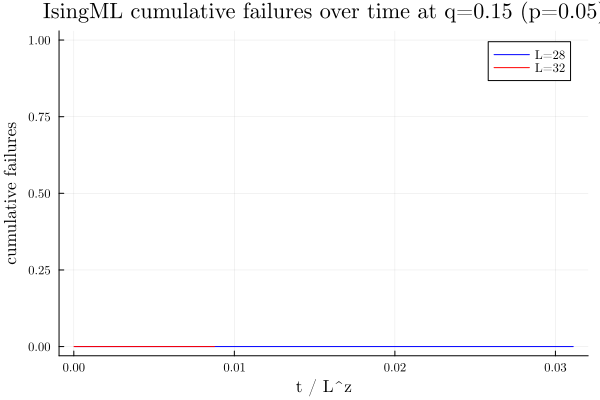

In [16]:
algo = "IsingML"
Ls   = 28:4:32
p    = 0.05
q   = 0.15
c = 0.05
f(L)    = exp(0.35L)

plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures]
    ts  = collect(1:length(M1s)) ./ f(L)
    plot!(plt, ts, M1s, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="cumulative failures", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

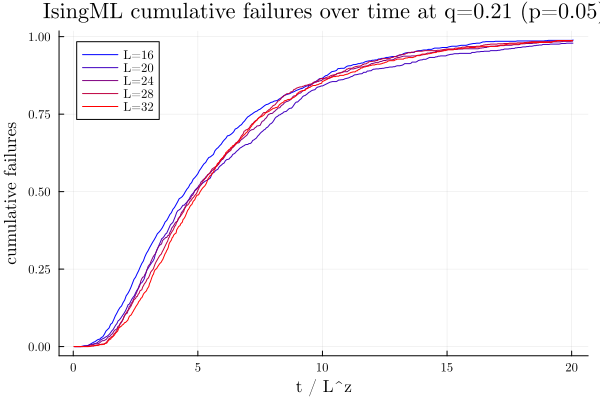

In [17]:
algo = "IsingML"
Ls   = 16:4:32
p    = 0.05
q   = 0.21
c = 0.05
f(L) = L^1.0

plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures]
    ts  = collect(1:length(M1s)) ./ f(L)
    plot!(plt, ts, M1s, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="cumulative failures", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

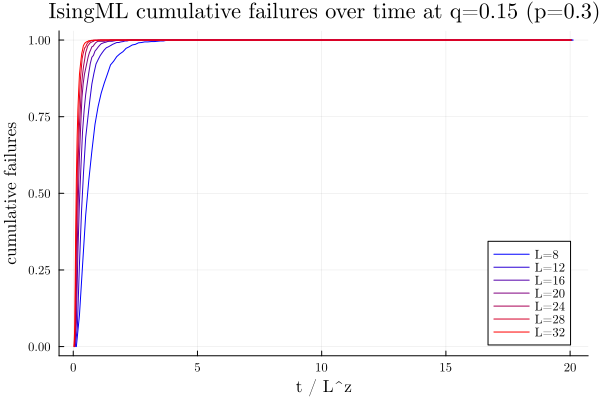

In [18]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
q   = 0.15
c = 0.8
f(L) = L

plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures]
    ts  = collect(1:length(M1s)) ./ f(L)
    plot!(plt, ts, M1s, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="cumulative failures", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

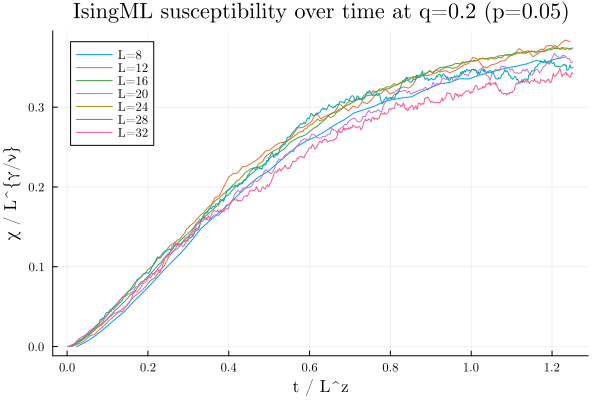

In [21]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.2
c = 0.05

f(L) = L^1.8
γ_ν  = 1.4

scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ f(L)
             for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]

t_max = minimum(maximum.(scaled_ts))

plt = plot()
for L in Ls
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:M1s]
    M2s = all_results[(algo, L, T, p, q, c)][:M2s]
    χ   = L^2 .* (M2s .- M1s.^2)
    ts  = collect(1:length(M1s)) ./ f(L)
    mask = ts .<= t_max
    plot!(plt, ts[mask], χ[mask] ./ L^γ_ν, label="L=$L")
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo susceptibility over time at q=$q (p=$p)")
plt

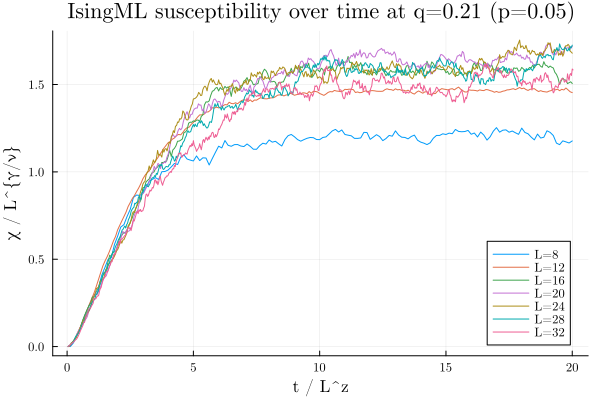

In [22]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.21
c = 0.05

f(L) = L^1.0
γ_ν  = 0.8

scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ f(L)
             for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]

t_max = minimum(maximum.(scaled_ts))

plt = plot()
for L in Ls
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:M1s]
    M2s = all_results[(algo, L, T, p, q, c)][:M2s]
    χ   = L^2 .* (M2s .- M1s.^2)
    ts  = collect(1:length(M1s)) ./ f(L)
    mask = ts .<= t_max
    plot!(plt, ts[mask], χ[mask] ./ L^γ_ν, label="L=$L")
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo susceptibility over time at q=$q (p=$p)")
plt

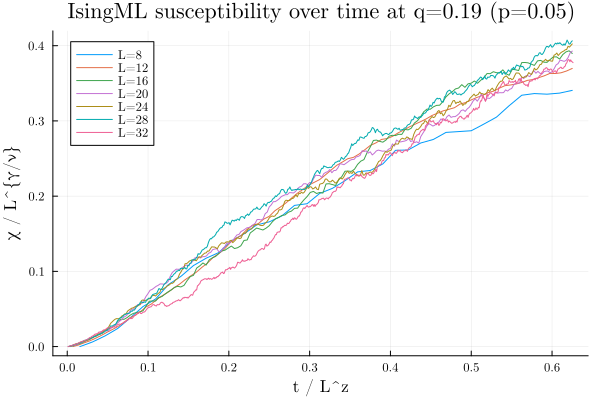

In [23]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.19
c = 0.05

f(L) = L^2.0
γ_ν  = 1.4

scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:M1s])) ./ f(L)
             for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]

t_max = minimum(maximum.(scaled_ts))

plt = plot()
for L in Ls
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:M1s]
    M2s = all_results[(algo, L, T, p, q, c)][:M2s]
    χ   = L^2 .* (M2s .- M1s.^2)
    ts  = collect(1:length(M1s)) ./ f(L)
    mask = ts .<= t_max
    plot!(plt, ts[mask], χ[mask] ./ L^γ_ν, label="L=$L")
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo susceptibility over time at q=$q (p=$p)")
plt

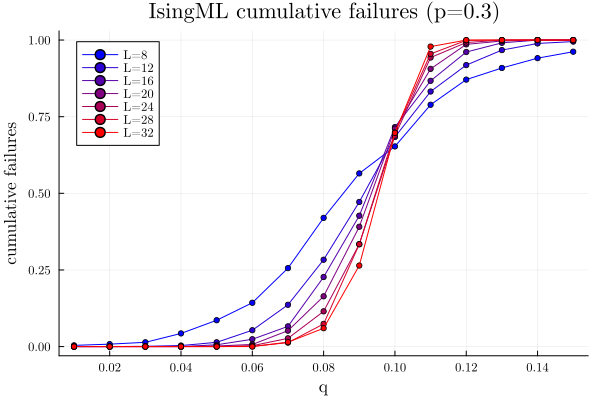

In [25]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][2L] for q in valid_qs]
    plot!(plt, valid_qs, cf, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="q", ylabel="cumulative failures", title="$algo cumulative failures (p=$p)")
plt

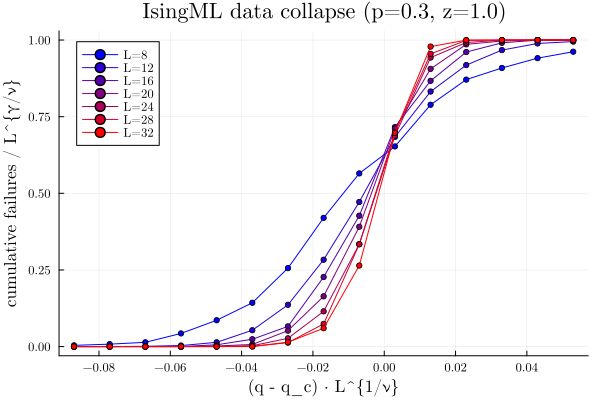

In [26]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
qc   = 0.097
ν    = Inf
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

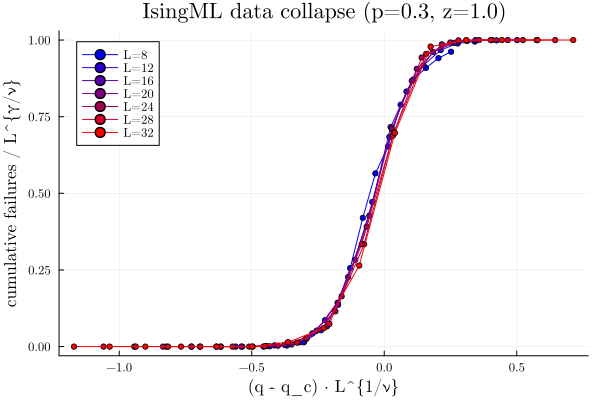

In [27]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.15
qc   = 0.097
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

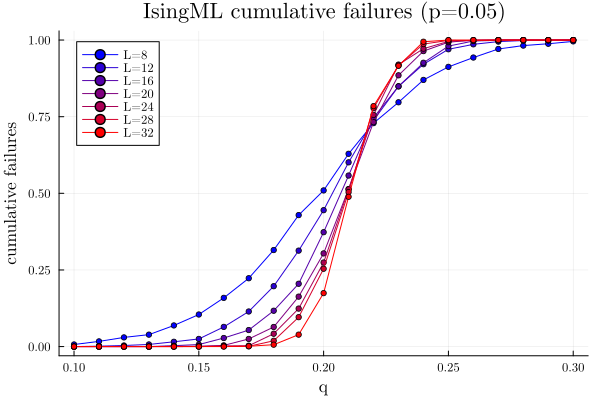

In [28]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][5L] for q in valid_qs]
    plot!(plt, valid_qs, cf, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="q", ylabel="cumulative failures", title="$algo cumulative failures (p=$p)")
plt

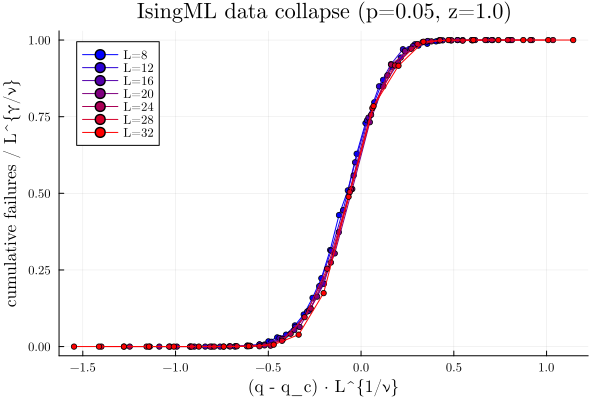

In [29]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.215
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 5 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

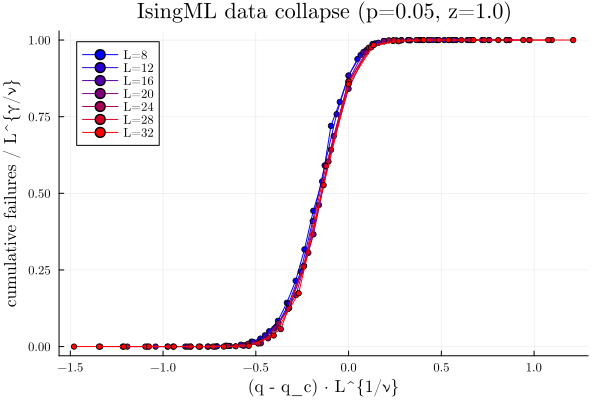

In [30]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.21
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 10 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

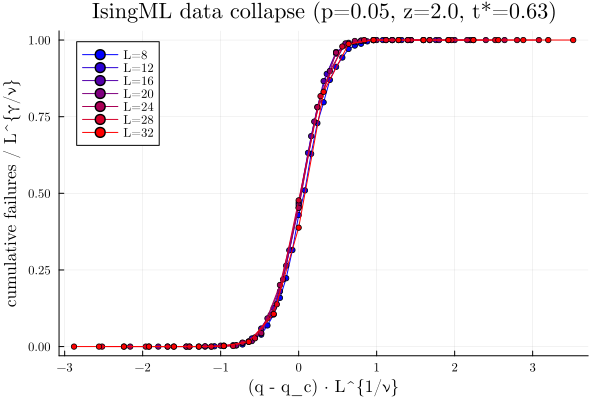

In [31]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.19
ν    = 1.0
z    = 2.0
γ_ν  = 0

# Find the largest scaled time t* compatible with all L:
# for each L pick any valid q, measure the raw data length, divide by L^z, then take the minimum
scaled_t_maxes = [
    length(all_results[(algo, L, 20L, p,
                        first(filter(q -> haskey(all_results, (algo, L, 20L, p, q, c)), qs)),
                        c)][:cumulative_failures]) / L^z
    for L in Ls if any(q -> haskey(all_results, (algo, L, 20L, p, q, c)), qs)
]
t_star = minimum(scaled_t_maxes)

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    isempty(valid_qs) && continue
    # Convert the shared scaled time back to a raw index for this L
    t_idx = round(Int, t_star * L^z)
    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}",
          title  = "$algo data collapse (p=$p, z=$z, t*=$(round(t_star, digits=2)))")
plt

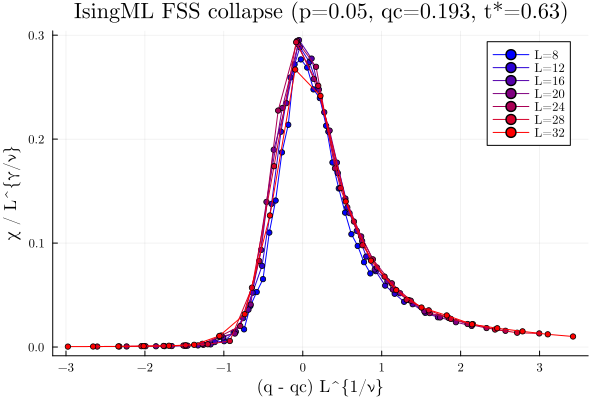

In [32]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.193
ν    = 1.0
γ_ν  = 1.5
z    = 2.0
plt  = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

# Largest scaled time t* = t / L^z compatible with every L
scaled_t_maxes = [
    length(all_results[(algo, L, 20L, p,
                        first(filter(q -> haskey(all_results, (algo, L, 20L, p, q, c)), qs)),
                        c)][:M1s]) / L^z
    for L in Ls if any(q -> haskey(all_results, (algo, L, 20L, p, q, c)), qs)
]
t_star = minimum(scaled_t_maxes)

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    isempty(valid_qs) && continue
    # Raw index from the shared scaled time
    t_idx = round(Int, t_star * L^z)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t_idx] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t_idx] for q in valid_qs]
    χ   = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}",
          title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)), t*=$(round(t_star,digits=2)))")
plt

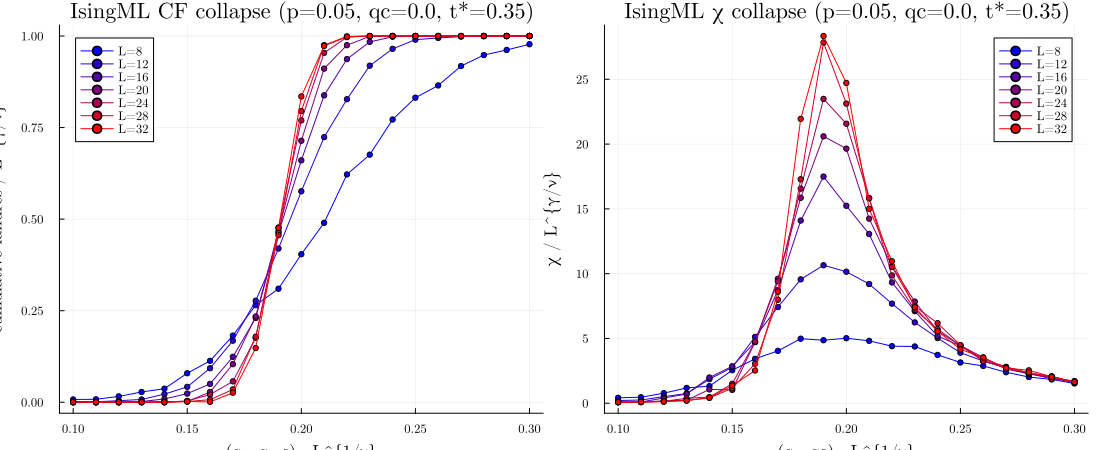

In [33]:
function fss_collapse(all_results, algo, Ls, p, c, qs;
                      qc_cf=0.19,  γ_ν_cf=0.0,
                      qc_χ=0.193,  γ_ν_χ=1.5,
                      ν=1.0, z=2.0, T_factor=20)
    colors = cgrad([:blue, :red], length(Ls), categorical=true)

    scaled_t_maxes = [
        length(all_results[(algo, L, T_factor*L, p,
                            first(filter(q -> haskey(all_results, (algo, L, T_factor*L, p, q, c)), qs)),
                            c)][:cumulative_failures]) / L^z
        for L in Ls if any(q -> haskey(all_results, (algo, L, T_factor*L, p, q, c)), qs)
    ]
    t_star = minimum(scaled_t_maxes)
    t_str  = round(t_star, digits=2)

    plt_cf = plot()
    plt_χ  = plot()

    for (i, L) in enumerate(Ls)
        T        = T_factor * L
        valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
        isempty(valid_qs) && continue
        t_idx = round(Int, t_star * L^z)

        # cumulative failures — uses its own qc and γ_ν
        cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] / L^γ_ν_cf
              for q in valid_qs]
        plot!(plt_cf, (valid_qs .- qc_cf) .* L^(1/ν), cf,
              m=3, label="L=$L", color=colors[i])

        # susceptibility — uses its own qc and γ_ν
        M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t_idx] for q in valid_qs]
        M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t_idx] for q in valid_qs]
        χ   = L^2 .* (M2s .- M1s.^2)
        plot!(plt_χ, (valid_qs .- qc_χ) .* L^(1/ν), χ ./ L^γ_ν_χ,
              m=3, label="L=$L", color=colors[i])
    end

    plot!(plt_cf,
          xlabel="(q - q_c) · L^{1/ν}", ylabel="cumulative failures / L^{γ/ν}",
          title="$algo CF collapse (p=$p, qc=$(round(qc_cf,digits=3)), t*=$t_str)")
    plot!(plt_χ,
          xlabel="(q - qc) · L^{1/ν}", ylabel="χ / L^{γ/ν}",
          title="$algo χ collapse (p=$p, qc=$(round(qc_χ,digits=3)), t*=$t_str)")

    plot(plt_cf, plt_χ, layout=(1,2), size=(1100, 450))
end

p = 0.05
c = 0.0
qc = 0.0
γ_ν = 0.0
z = 2.17
ν = Inf

fss_collapse(all_results, "IsingML", 8:4:32, p, c, 0.1:0.01:0.3;
             qc_cf=qc,  γ_ν_cf=0.0,
             qc_χ=qc,  γ_ν_χ=γ_ν,
             ν=ν, z=z)

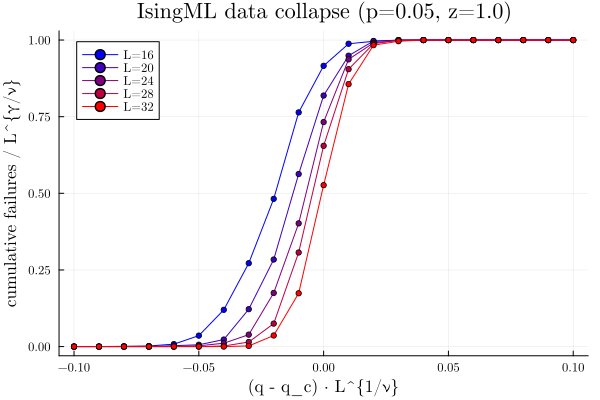

In [34]:
algo = "IsingML"
Ls   = 16:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.2
ν    = Inf
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 10 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][20*16] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

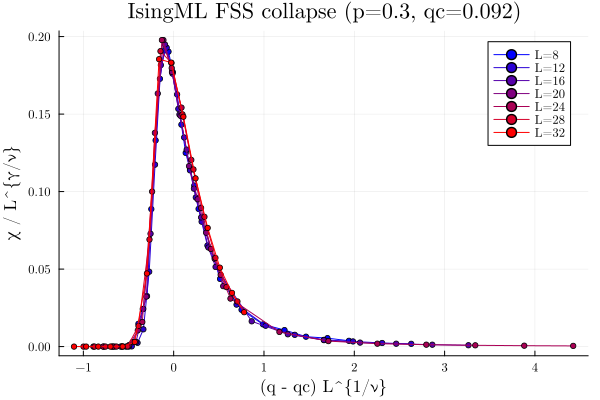

In [35]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
c    = 0.8
qs   = 0.01:0.01:0.5
qc   = 0.092
ν    = 4/3
γ_ν  = 2.0
z    = 1.0
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

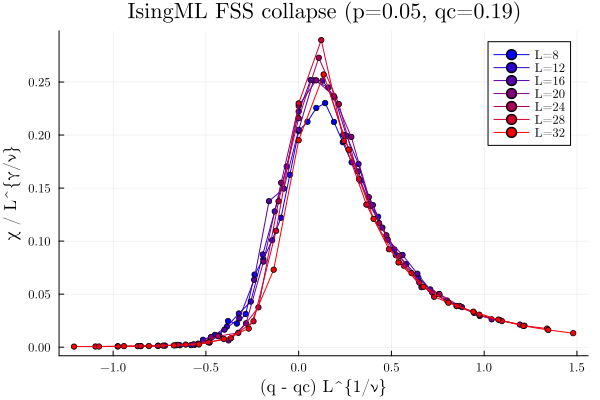

In [36]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.19
ν    = 4/3
γ_ν  = 1.4
z    = 1.0
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, 0.5*T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

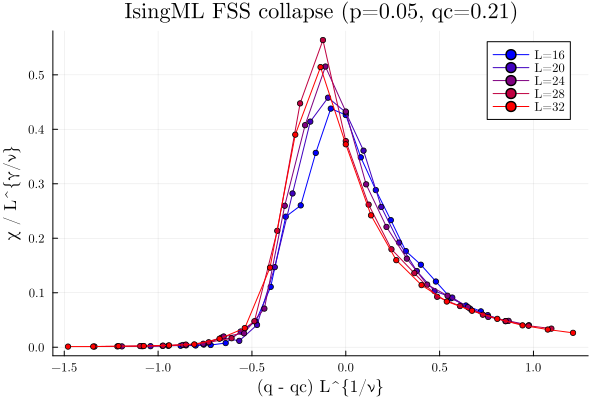

In [37]:
algo = "IsingML"
Ls   = 16:4:32
p    = 0.05
c    = 0.05
qs   = 0.1:0.01:0.3
qc   = 0.21
ν    = 4/3
γ_ν  = 1.2
z    = 1.
plt = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)
for (i, L) in enumerate(Ls)
    T = 20L
    t = round(Int, 0.5*T * (L / maximum(Ls))^z)
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)
    M1s = [all_results[(algo, L, T, p, q, c)][:M1s][t] for q in valid_qs]
    M2s = [all_results[(algo, L, T, p, q, c)][:M2s][t] for q in valid_qs]
    χ = L^2 .* (M2s .- M1s.^2)
    plot!(plt, (valid_qs .- qc) .* L^(1/ν), χ ./ L^γ_ν, m=3, label="L=$L", color=colors[i])
end
plot!(plt, xlabel="(q - qc) L^{1/ν}", ylabel="χ / L^{γ/ν}", title="$algo FSS collapse (p=$p, qc=$(round(qc,digits=3)))")
plt

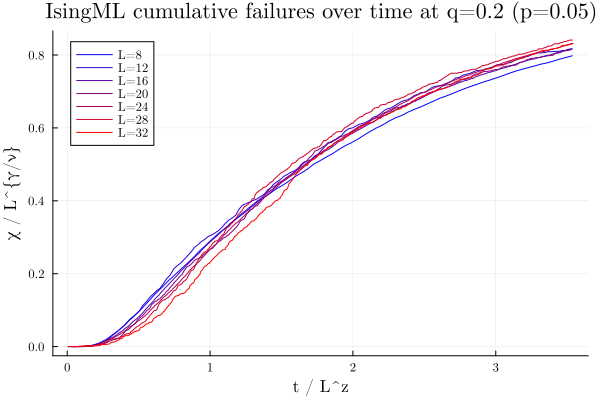

In [39]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.05
q   = 0.2
c = 0.05
z    = 1.5
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:cumulative_failures])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

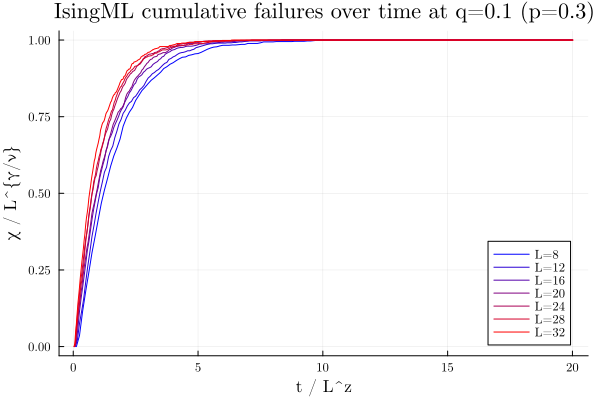

In [40]:
algo = "IsingML"
Ls   = 8:4:32
p    = 0.3
q   = 0.1
c = 1.0
z    = 1.0
γ_ν  = 0
scaled_ts = [collect(1:length(all_results[(algo, L, 20L, p, q, c)][:cumulative_failures])) ./ L^z
for L in Ls if haskey(all_results, (algo, L, 20L, p, q, c))]
t_max = minimum(maximum.(scaled_ts))
# println(t_max)
plt = plot()
colors = range(colorant"blue", colorant"red", length=length(Ls))
for (i, L) in enumerate(Ls)
    T = 20L
    haskey(all_results, (algo, L, T, p, q, c)) || continue
    M1s = all_results[(algo, L, T, p, q, c)][:cumulative_failures] ./ L^(γ_ν)
    ts  = collect(1:length(M1s)) ./ L^z
    mask = ts .<= t_max
    plot!(plt, ts[mask], M1s[mask], label="L=$L", color=colors[i])
end
plot!(plt, xlabel="t / L^z", ylabel="χ / L^{γ/ν}", title="$algo cumulative failures over time at q=$q (p=$p)")
plt

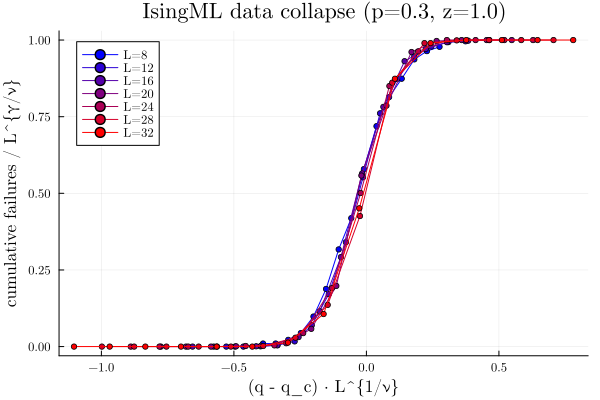

In [41]:
algo = "IsingML"
Ls   = 8:4:32
plt    = plot()
colors = cgrad([:blue, :red], length(Ls), categorical=true)

p    = 0.3
c    = 1.0
qs   = 0.01:0.01:0.15
qc   = 0.092
ν    = 4/3
z    = 1.0
γ_ν  = 0

for (i, L) in enumerate(Ls)
    T = 20L
    valid_qs = filter(q -> haskey(all_results, (algo, L, T, p, q, c)), qs)

    # Use z-scaled time index: t* = 2 (in units of L^z), so raw index = round(2 * L^z)
    t_idx = round(Int, 2 * L^z)

    cf = [all_results[(algo, L, T, p, q, c)][:cumulative_failures][t_idx] ./ L^(γ_ν) for q in valid_qs]

    plot!(plt, (valid_qs .- qc) .* L^(1/ν), cf, m=3, label="L=$L", color=colors[i])#, seriestype=:scatter)
end

plot!(plt, xlabel = "(q - q_c) · L^{1/ν}", ylabel = "cumulative failures / L^{γ/ν}", title  = "$algo data collapse (p=$p, z=$z)")
plt

In [43]:
function make_decoder(algo, q, c)
    if algo == "MV"
        return MajorityVote()
    elseif algo == "TOOM"
        return Toom()
    elseif algo == "UV"
        return UnanimousVote()
    elseif algo == "IsingML"
        isnan(c) && error("IsingML requires --c")
        return IsingML(q, c)
    else
        error("Unknown --algo=$(algo)")
    end
end

function sample(L::Int, T::Int, p::Float64, q::Float64, decoder::AbstractDecoder)
    ρ = initialstate(L)
    Ms = zeros(Float64, T+1)
    Es = zeros(Float64, T+1)


    Ms[1] = magnetization(ρ)
    Es[1] = energy(ρ)

    for t in 1:T
        ρ = noiselayer(ρ, p)
        checks = measure(ρ, q)
        ρ = correct(ρ, checks, decoder)
        Ms[t+1] = magnetization(ρ)
    end
    return Ms
end

function sample(L::Int, T::Int, p::Float64, q::Float64, decoder::AbstractDecoder, samples::Int)
    # (1) averaged time series
    M1s = zeros(Float64, T+1)
    M2s = zeros(Float64, T+1)

    # (3) averaged instant failure rate at each timestep
    instant_failures    = zeros(Float64, T+1)

    # (4) averaged cumulative failure rate at each timestep
    cumulative_failures = zeros(Float64, T+1)

    for i in 1:samples
        Ms = sample(L, T, p, q, decoder)

        # (1)
        M1s .+= Ms
        M2s .+= Ms.^2

        # (3)
        instant_failures .+= Ms .> 0.5

        # (4)
        ever_failed = false
        for t in 1:T+1
            ever_failed |= Ms[t] > 0.5
            cumulative_failures[t] += ever_failed
        end
    end

    M1s                ./= samples
    M2s                ./= samples
    instant_failures   ./= samples
    cumulative_failures ./= samples

    return M1s, M2s, instant_failures, cumulative_failures
end

sample (generic function with 2 methods)

In [44]:
# data = Dict{Tuple{Int, Int, Float64, Float64, Float64}, Tuple{Vector, Vector, Vector, Vector}}()

In [45]:
algo = "IsingML"
L = 40
T = 2L
p, q, c = 0.3, 0.1, 0.8
samples = 1
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, instant_failures, cumulative_failures = sample(L, T, p, q, decoder, samples)
dt = time() - t0

# data[(L, T, p, q, c)] = (M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist)

cumulative_failures[end]

1.0

In [46]:
algo = "IsingML"
L = 4
T = 2L
p, q, c = 0.3, 0.105, 0.8
samples = 100000
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, instant_failures, cumulative_failures = sample(L, T, p, q, decoder, samples)
dt = time() - t0

data[(L, T, p, q, c)] = (M1s, M2s, instant_failures, cumulative_failures)

cumulative_failures[end]

UndefVarError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [47]:
algo = "IsingML"
L = 8
T = 2L
p, q, c = 0.3, 0.105, 0.8
samples = 10000
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, instant_failures, cumulative_failures = sample(L, T, p, q, decoder, samples)
dt = time() - t0

data[(L, T, p, q, c)] = (M1s, M2s, instant_failures, cumulative_failures)

cumulative_failures[end]

UndefVarError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [48]:
algo = "IsingML"
L = 12
T = 2L
p, q, c = 0.3, 0.105, 0.8
samples = 1000
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, instant_failures, cumulative_failures = sample(L, T, p, q, decoder, samples)
dt = time() - t0

data[(L, T, p, q, c)] = (M1s, M2s, instant_failures, cumulative_failures)

cumulative_failures[end]

UndefVarError: UndefVarError: `data` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [51]:
algo = "IsingML"
L = 16
T = 2L
p, q, c = 0.3, 0.1, 0.8
samples = 1000
tag     = "test"

decoder = make_decoder(algo, q, c)

# Warmup to avoid timing JIT compilation
sample(2, 2, 0.0, 0.0, decoder, 1)

t0 = time()
M1s, M2s, instant_failures, cumulative_failures = sample(L, T, p, q, decoder, samples)
dt = time() - t0

# data[(L, T, p, q, c)] = (M1s, M2s, E1s, E2s, instant_failures, cumulative_failures, Ms_hist, Es_hist)

cumulative_failures[end]

0.709